# Stakeholder Dashboard Challenge

---

## Overview

You have access to 2+ years of real market data (stock prices from Yahoo Finance). Your organization is building a product and wants a dashboard, but stakeholders disagree on what it should show.

**Head of Strategy:**
> "We're building for institutional investors. Show volatility by asset, correlation matrices, capital efficiency metrics, and tail risk. Make it serious."

**Product Lead:**
> "Actually, our retail users want simplicity. Show moving averages, momentum, and 'is now a good time to buy?' Make it visual and accessible."

**Engineering:**
> "Whatever you build, pull live data from Yahoo Finance with a fallback CSV if the API fails."

---

## Your Assignment

Build a professional dashboard that serves **one specific stakeholder persona** and present your design choices.

**Deliverable:**
1. A functional dashboard (notebook cells with visualizations)
2. A presentation of your findings covering:
   - Who this dashboard is designed for (audience persona)
   - Which 3-5 metrics you chose and why they matter for this audience
   - What business decision or action they would take based on what they see
   - Why you rejected other metrics/audiences
3. **Share your work via GitHub** (create a repo, push your notebook and analysis)

**Technical Requirements:**
- Load data via yfinance (with CSV fallback if the API fails)
- Clean and validate the data
- Calculate relevant metrics
- Create professional visualizations (subplots, clear labels, appropriate scales)

---

In [18]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries loaded")

✓ Libraries loaded


In [20]:
# Load market data: try live first, fall back to CSV
tickers = ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'TSLA', 'META', 'AMZN', 'BRK-B']
start_date = (datetime.now() - timedelta(days=730)).strftime('%Y-%m-%d')
end_date = datetime.now().strftime('%Y-%m-%d')

try:
    data = yf.download(tickers, start=start_date, end=end_date, progress=False)['Close']
    print(f"✓ Live data loaded from Yahoo Finance ({len(data)} trading days)")
except:
    data = pd.read_csv('data/week1_market_data_fallback.csv', index_col=0, parse_dates=True)
    print(f"✓ Fallback data loaded from CSV ({len(data)} trading days)")

print(f"  Assets: {list(data.columns)}")
print(f"  Period: {data.index[0].date()} to {data.index[-1].date()}")
print(f"  Data shape: {data.shape}")

✓ Live data loaded from Yahoo Finance (501 trading days)
  Assets: ['AAPL', 'AMZN', 'BRK-B', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
  Period: 2024-08-19 to 2026-08-18
  Data shape: (501, 8)


## Data Exploration & Analysis

Clean the data, calculate metrics, and build your dashboard below.

In [21]:
# Your analysis and dashboard code here
data.head()

Ticker,AAPL,AMZN,BRK-B,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,,
2024-08-19,224.016068,178.220001,448.769989,165.394714,525.750732,415.755829,129.786102,222.720001
2024-08-20,224.630905,178.880005,448.359985,165.900787,523.217773,418.980988,127.040619,221.100006
2024-08-21,224.521805,180.110001,446.600006,164.580978,531.591553,418.330139,128.288544,223.270004
2024-08-22,222.667358,176.130005,449.029999,162.546631,528.382996,409.857758,123.536377,210.660004
2024-08-23,224.958191,177.039993,453.380005,164.352722,524.479187,411.080780,129.157120,220.320007


In [22]:
print("\nMissing values:")
print(data.isna().sum())



Missing values:
Ticker
AAPL     0
AMZN     0
BRK-B    0
GOOGL    0
META     0
MSFT     0
NVDA     0
TSLA     0
dtype: int64


In [23]:
# Calculate daily returns: (Price_today - Price_yesterday) / Price_yesterday
returns = data.pct_change().dropna()

# Convert to percentage
returns_pct = returns * 100

print("Daily Returns (first 5 days):")
print(returns_pct.head())
print(f"\nDaily Returns Statistics:")
print(returns_pct.describe().round(3))

Daily Returns (first 5 days):
Ticker          AAPL      AMZN     BRK-B     GOOGL      META      MSFT  \
Date                                                                     
2024-08-20  0.274461  0.370331 -0.091362  0.305979 -0.481779  0.775734   
2024-08-21 -0.048569  0.687609 -0.392537 -0.795541  1.600439 -0.155341   
2024-08-22 -0.825954 -2.209758  0.544109 -1.236077 -0.603576 -2.025286   
2024-08-23  1.028814  0.516657  0.968756  1.111122 -0.738822  0.298402   
2024-08-26  0.149876 -0.869856  0.244825  0.326060 -1.303016 -0.791772   

Ticker          NVDA      TSLA  
Date                            
2024-08-20 -2.115391 -0.727368  
2024-08-21  0.982304  0.981455  
2024-08-22 -3.704280 -5.647870  
2024-08-23  4.549869  4.585590  
2024-08-26 -2.249363 -3.227124  

Daily Returns Statistics:
Ticker     AAPL     AMZN    BRK-B    GOOGL     META     MSFT     NVDA     TSLA
count   500.000  500.000  500.000  500.000  500.000  500.000  500.000  500.000
mean      0.081    0.098    0.029  

In [24]:
# Volatility = Standard deviation of returns
daily_volatility = returns.std()

# Annualize volatility (there are ~252 trading days per year)
annual_volatility = daily_volatility * np.sqrt(252)

# Create summary table
volatility_df = pd.DataFrame({
    'Daily Volatility (%)': daily_volatility * 100,
    'Annual Volatility (%)': annual_volatility * 100,
    'Avg Daily Return (%)': returns_pct.mean(),
    'Max Daily Return (%)': returns_pct.max(),
    'Min Daily Return (%)': returns_pct.min(),
})

print("\n" + "="*70)
print("VOLATILITY & RETURN ANALYSIS")
print("="*70)
print(volatility_df.round(2))

print(f"\nInterpretation:")
print(f"  - Higher volatility = more risky (bigger price swings)")
print(f"  - Lower volatility = more stable (smaller price swings)")
print(f"  - Annual volatility of 30% = typical for tech stocks")


VOLATILITY & RETURN ANALYSIS
        Daily Volatility (%)  Annual Volatility (%)  Avg Daily Return (%)  \
Ticker                                                                      
AAPL                    1.81                  28.77                  0.08   
AMZN                    2.15                  34.09                  0.10   
BRK-B                   1.09                  17.28                  0.03   
GOOGL                   2.01                  31.90                  0.17   
META                    2.38                  37.78                  0.03   
MSFT                    1.82                  28.85                  0.05   
NVDA                    2.84                  45.08                  0.15   
TSLA                    3.79                  60.24                  0.15   

        Max Daily Return (%)  Min Daily Return (%)  
Ticker                                              
AAPL                   15.33                 -9.25  
AMZN                   15.32            

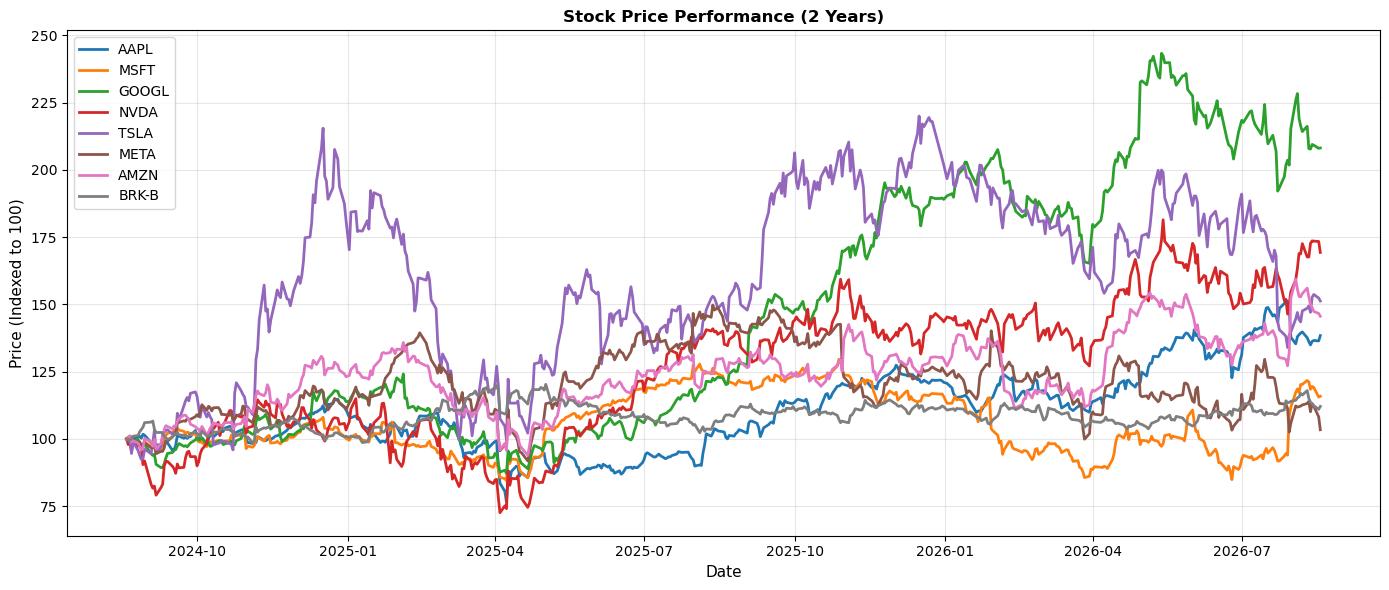

Chart saved: stock_prices.png

Interpretation:
  Best performer: GOOGL ($208 vs starting $100)
  Worst performer: META ($103 vs starting $100)


In [25]:
 # Normalize prices to 100 at start (for easier comparison)
normalized_prices = (data / data.iloc[0] * 100)

# Plot normalized prices
fig, ax = plt.subplots(figsize=(14, 6))

for stock in tickers:
    ax.plot(normalized_prices.index, normalized_prices[stock], linewidth=2, label=stock)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price (Indexed to 100)', fontsize=11)
ax.set_title('Stock Price Performance (2 Years)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stock_prices.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: stock_prices.png")
print(f"\nInterpretation:")
best_performer = normalized_prices.iloc[-1].idxmax()
worst_performer = normalized_prices.iloc[-1].idxmin()
print(f"  Best performer: {best_performer} (${normalized_prices.iloc[-1][best_performer]:.0f} vs starting $100)")
print(f"  Worst performer: {worst_performer} (${normalized_prices.iloc[-1][worst_performer]:.0f} vs starting $100)")

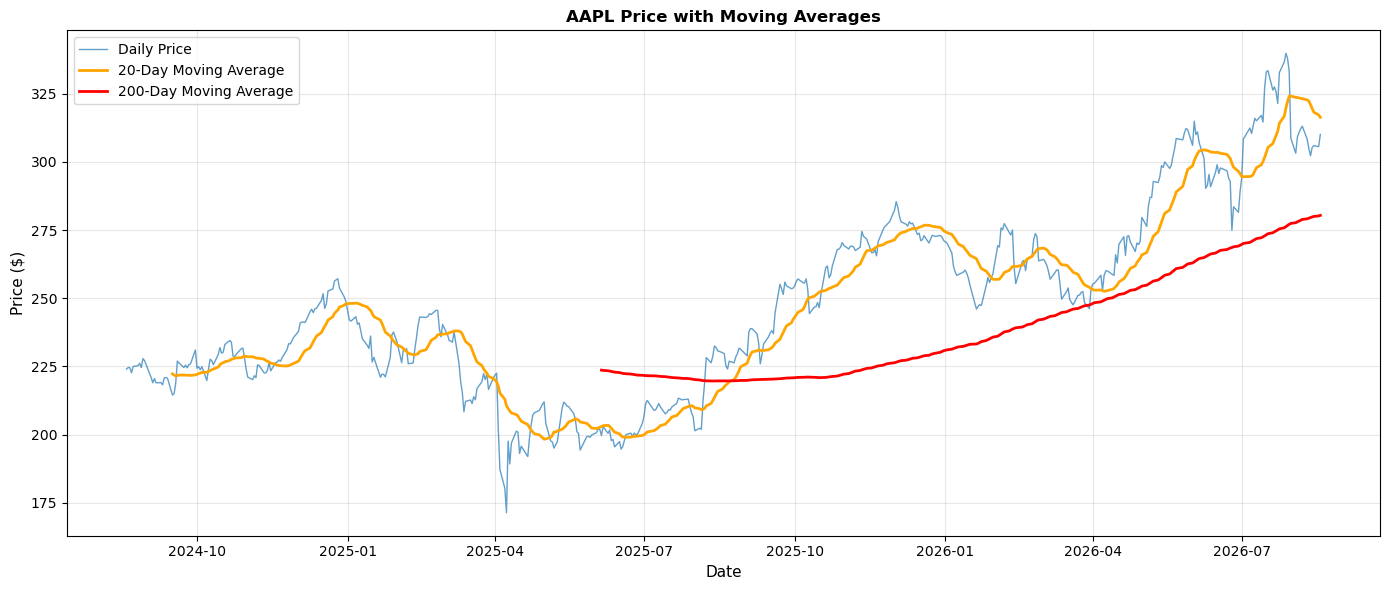

Chart saved: moving_averages.png

Moving Average Interpretation:
  20-day MA: Shows short-term trend (1 month)
  200-day MA: Shows long-term trend (1 year)
  Golden Cross: 20-day MA crosses above 200-day = bullish signal
  Death Cross: 20-day MA crosses below 200-day = bearish signal


In [26]:
# Calculate moving averages for Apple
stock_to_analyze = 'AAPL'
ma_short = data[stock_to_analyze].rolling(window=20).mean()  # 20-day MA
ma_long = data[stock_to_analyze].rolling(window=200).mean()  # 200-day MA

# Plot with moving averages
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(data.index, data[stock_to_analyze], label='Daily Price', linewidth=1, alpha=0.7)
ax.plot(ma_short.index, ma_short, label='20-Day Moving Average', linewidth=2, color='orange')
ax.plot(ma_long.index, ma_long, label='200-Day Moving Average', linewidth=2, color='red')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price ($)', fontsize=11)
ax.set_title(f'{stock_to_analyze} Price with Moving Averages', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: moving_averages.png")
print(f"\nMoving Average Interpretation:")
print(f"  20-day MA: Shows short-term trend (1 month)")
print(f"  200-day MA: Shows long-term trend (1 year)")
print(f"  Golden Cross: 20-day MA crosses above 200-day = bullish signal")
print(f"  Death Cross: 20-day MA crosses below 200-day = bearish signal")

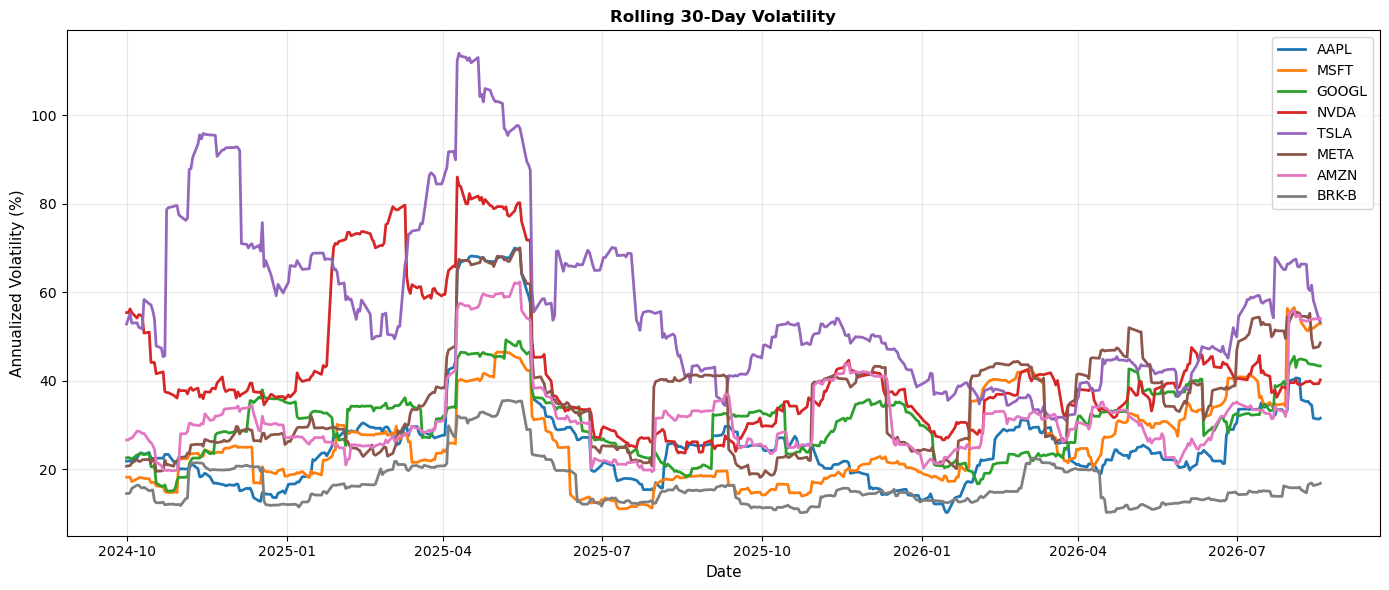

Chart saved: rolling_volatility.png

Key Observations:
  - Volatility changes over time (not constant)
  - Market crises cause volatility spikes
  - Current volatility useful for traders


In [27]:
# Calculate rolling volatility (30-day window)
rolling_volatility = returns.rolling(window=30).std() * np.sqrt(252) * 100

# Plot rolling volatility
fig, ax = plt.subplots(figsize=(14, 6))

for stock in tickers:
    ax.plot(rolling_volatility.index, rolling_volatility[stock], linewidth=2, label=stock)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Annualized Volatility (%)', fontsize=11)
ax.set_title('Rolling 30-Day Volatility', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: rolling_volatility.png")
print(f"\nKey Observations:")
print(f"  - Volatility changes over time (not constant)")
print(f"  - Market crises cause volatility spikes")
print(f"  - Current volatility useful for traders")


Correlation Matrix (Daily Returns):
Ticker   AAPL   AMZN  BRK-B  GOOGL   META   MSFT   NVDA   TSLA
Ticker                                                        
AAPL    1.000  0.365  0.333  0.345  0.363  0.314  0.329  0.382
AMZN    0.365  1.000  0.213  0.563  0.577  0.509  0.454  0.445
BRK-B   0.333  0.213  1.000  0.110  0.143  0.153  0.020  0.210
GOOGL   0.345  0.563  0.110  1.000  0.420  0.301  0.389  0.458
META    0.363  0.577  0.143  0.420  1.000  0.385  0.454  0.417
MSFT    0.314  0.509  0.153  0.301  0.385  1.000  0.438  0.332
NVDA    0.329  0.454  0.020  0.389  0.454  0.438  1.000  0.438
TSLA    0.382  0.445  0.210  0.458  0.417  0.332  0.438  1.000


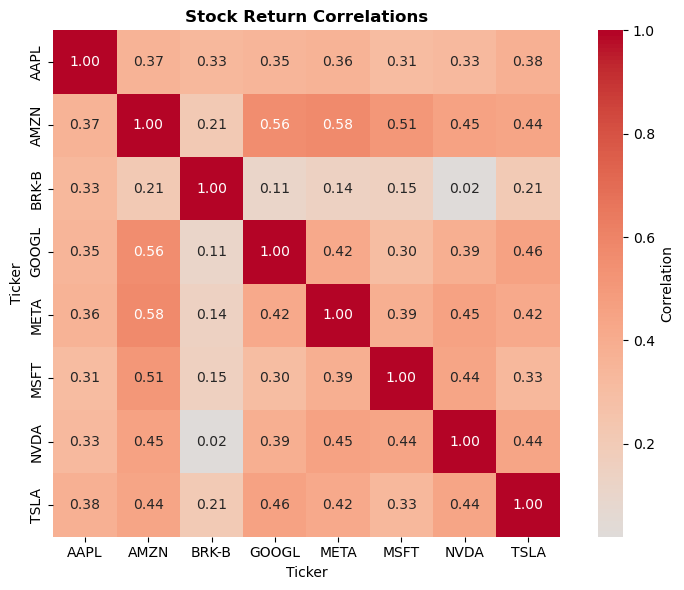

Chart saved: correlation_heatmap.png

Interpretation:
  Correlation = 1.0: Move perfectly together (no diversification benefit)
  Correlation = 0.0: Move independently (good diversification)
  Correlation < 0: Move opposite (excellent diversification)


In [28]:
# Calculate correlation between daily returns
correlation = returns.corr()

print("\nCorrelation Matrix (Daily Returns):")
print(correlation.round(3))

# Visualize as heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Stock Return Correlations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: correlation_heatmap.png")
print(f"\nInterpretation:")
print(f"  Correlation = 1.0: Move perfectly together (no diversification benefit)")
print(f"  Correlation = 0.0: Move independently (good diversification)")
print(f"  Correlation < 0: Move opposite (excellent diversification)")

## Presentation of Findings

Present your dashboard design covering:

1. **Audience Persona:** Who is this dashboard for? (Retail investor, CIO, fund manager, etc.)
2. **Metrics Rationale:** Which 3-5 metrics did you include and why each matters for your audience?
3. **Business Decision:** What specific decision or action would your audience take based on this dashboard?
4. **Trade-offs:** What did you exclude and why? Why not build it for everyone?

*Add your analysis and findings here. Present in whatever format you prefer (written narrative, bullet points, slides, etc.).*

1. Audience Persona

    The dashboard is designed for self-directed retail investor who invests primarily in large-cap U.S. stocks and wants to balance growth opportunities with portfolio risk.

2. Metric Rationale
    
    a. two-year normalized price performance
    Stock prices are normalized to 100 at the beginning of the period so that stocks with very different dollar prices can be compared directly.

    Over the two-year period, GOOGL was the strongest performer, ending at approximately 208 relative to a starting value of 100. META showed the weakest overall performance among the stocks in this sample.

    b. 20-day and 200-day moving averyage (AAPL)
    AAPL's price remains above its 200-day moving average, suggesting that the long-term remains postive. However, the price has recentlu fallen below its 20-day moving average, indivating some short-term weakness or consolidation.

    c. 30-day rolling volatility  
    Rolling volatility shows how much each stock's returns fluctuate over time.

    TSLA had the highest volatility, while BRK-B had the lowest, showing a clear difference in risk between the stocks.

    d. Return correlation  
    Correlation shows how closely stocks move together and helps evaluate diversification.

    AMZN and META had a relatively high correlation of 0.58, while BRK-B and NVDA had a very low correlation of 0.02.

3. Business Decision

    The investor can use the dashboard to decide how to allocate or rebalance the portfolio. For example, GOOGL had the strongest two-year performance, while TSLA showed much higher volatility. BRK-B had lower volatility and a very low correlation with NVDA (0.02), so it could be used to reduce risk in a technology-heavy portfolio.

    For AAPL, the price is above the 200-day moving average but below the 20-day moving average, suggesting a positive long-term trend but some short-term weakness. An investor many decide to hold the position or wait before increasing it.

4. Trade-offs

    I focused on performance, trend, volatility, and correlation because they directly support a retail investor's decisions about return and risk.

    I did not include financial metrics such as Sharpe ratio, beta, and portfolio optimization, which would increase my complexity to the dashboard.

    I also focused on a small group of U.S. stocks instead of the entire martket, which makes the dashboard easier to compare and understand but limits how broadly the results can be applied.